RELOJ MINUTERO HORERO SEGUNDERO

Líneas detectadas: 25
Líneas filtradas: 4
Líneas únicas: 3

✓ HORA: 12:26:12


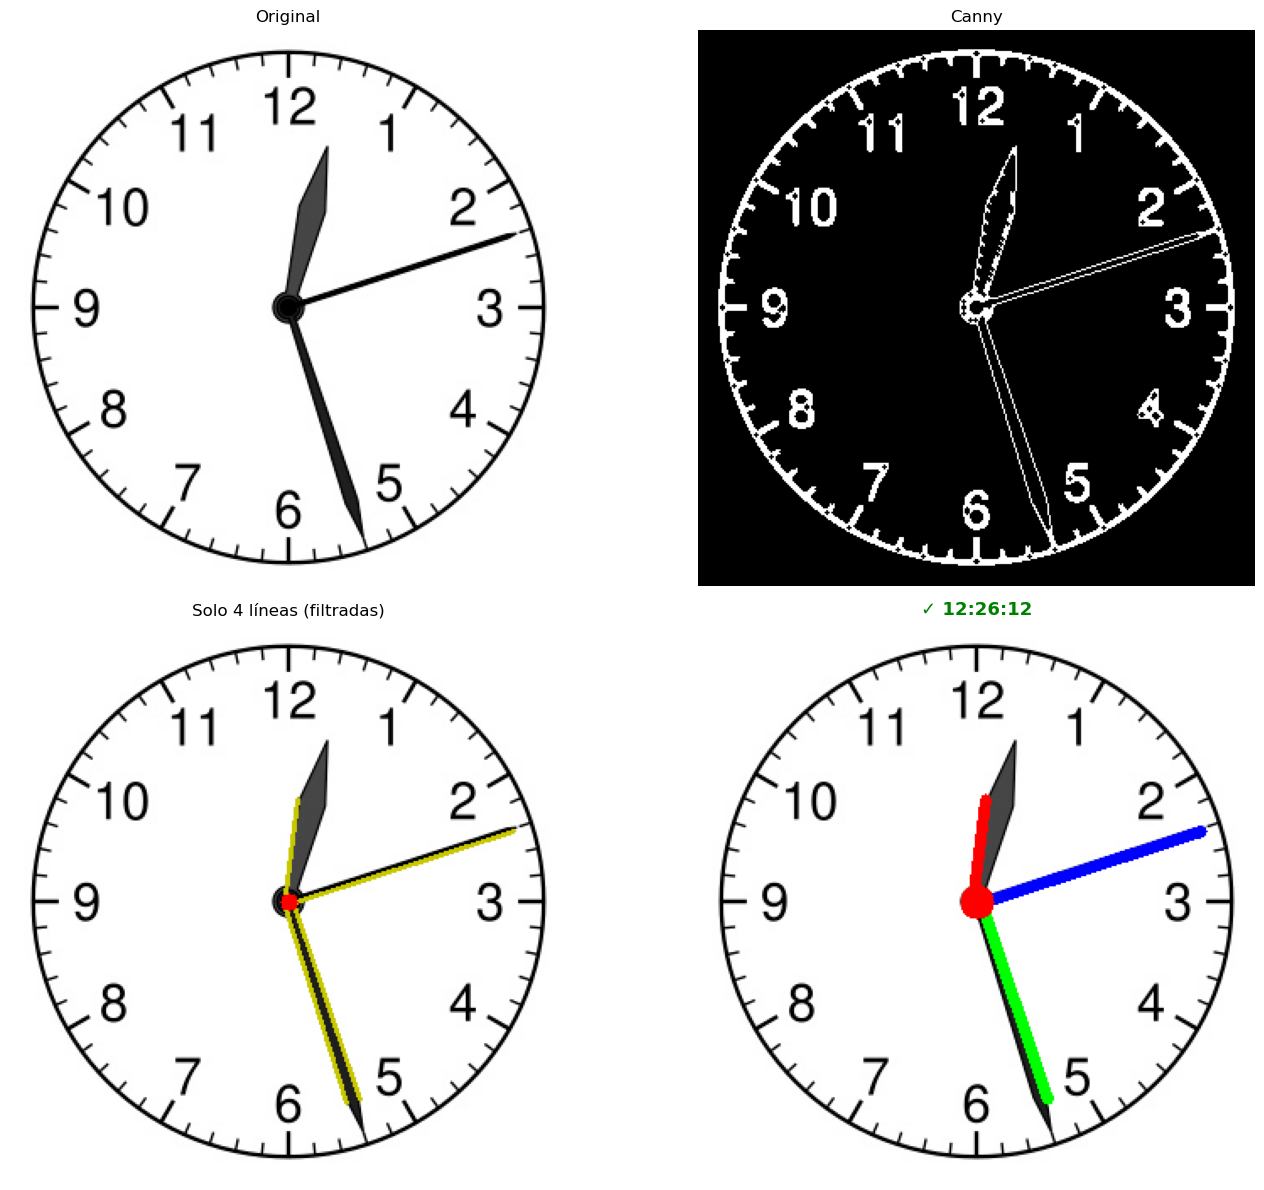

In [68]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

img = cv2.imread('img9.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)#img en gris

#centro
img_height, img_width = img.shape[:2]
centro_x, centro_y = img_width // 2, img_height // 2
radio_filtro = min(img_height, img_width) // 2 - 20

#mejora contraste
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
gray_mejorado = clahe.apply(gray)

# Canny 
bordes = cv2.Canny(gray_mejorado, 50, 150)  # Valores mas altos = menos ruido

#limpia bordes
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
bordes = cv2.dilate(bordes, kernel, iterations=1)
bordes = cv2.erode(bordes, kernel, iterations=1)

# Hough MÁS ESTRICTO
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=50,  # threshold 
                         minLineLength=40,  # lineas mas largas
                         maxLineGap=5)

print(f"Líneas detectadas: {len(lineas) if lineas is not None else 0}")

def obtener_angulo(x1, y1, x2, y2, cx, cy):
    dist1 = math.sqrt((x1 - cx)**2 + (y1 - cy)**2)
    dist2 = math.sqrt((x2 - cx)**2 + (y2 - cy)**2)
    
    if dist1 > dist2:
        dx, dy = x1 - cx, cy - y1
    else:
        dx, dy = x2 - cx, cy - y2
    
    angulo = math.degrees(math.atan2(dy, dx))
    return (90 - angulo) % 360

#filtrar lineas
manecillas = []

if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        
        dist1 = math.sqrt((x1 - centro_x)**2 + (y1 - centro_y)**2)
        dist2 = math.sqrt((x2 - centro_x)**2 + (y2 - centro_y)**2)
        distancia_centro = min(dist1, dist2)
        distancia_max_centro = max(dist1, dist2)
        
        # FILTROS 
        if (distancia_centro < 30 and           # Pasa muy cerca del centro  
            distancia_max_centro < radio_filtro and # Está dentro del reloj
            50 < longitud < 150):                 # Solo líneas largas
            
            angulo = obtener_angulo(x1, y1, x2, y2, centro_x, centro_y)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

print(f"Líneas filtradas: {len(manecillas)}")

def eliminar_duplicados(mans, tol=20):
    if not mans:
        return []
    mans_sorted = sorted(mans, key=lambda x: x['angulo'])
    grupos = []
    grupo_actual = [mans_sorted[0]]
    
    for i in range(1, len(mans_sorted)):
        diff = abs(mans_sorted[i]['angulo'] - grupo_actual[-1]['angulo'])
        diff = min(diff, 360 - diff)
        if diff < tol:
            grupo_actual.append(mans_sorted[i])
        else:
            grupos.append(grupo_actual)
            grupo_actual = [mans_sorted[i]]
    
    grupos.append(grupo_actual)
    return [max(g, key=lambda x: x['longitud']) for g in grupos]

manecillas_unicas = eliminar_duplicados(manecillas, tol=20)

print(f"Líneas únicas: {len(manecillas_unicas)}")

if len(manecillas_unicas) >= 3:
    manecillas_unicas.sort(key=lambda x: x['longitud'])
    
    horario = manecillas_unicas[-3]
    minutero = manecillas_unicas[-2]
    segundero = manecillas_unicas[-1]
    
    hora = int((horario['angulo'] / 30) % 12) or 12
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60)
    
    print(f"\n✓ HORA: {hora:02d}:{minutos:02d}:{segundos:02d}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    #mostrar
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(bordes, cmap='gray')
    axes[0, 1].set_title('Canny')
    axes[0, 1].axis('off')
    
    img_all = img_rgb.copy()
    for m in manecillas:
        cv2.line(img_all, (m['puntos'][0], m['puntos'][1]),
                (m['puntos'][2], m['puntos'][3]), (200, 200, 0), 2)
    cv2.circle(img_all, (centro_x, centro_y), 5, (255, 0, 0), -1)
    axes[1, 0].imshow(img_all)
    axes[1, 0].set_title(f'Solo {len(manecillas)} líneas (filtradas)')
    axes[1, 0].axis('off')
    
    img_final = img_rgb.copy()
    cv2.line(img_final, (horario['puntos'][0], horario['puntos'][1]),
             (horario['puntos'][2], horario['puntos'][3]), (255, 0, 0), 5)
    cv2.line(img_final, (minutero['puntos'][0], minutero['puntos'][1]),
             (minutero['puntos'][2], minutero['puntos'][3]), (0, 255, 0), 5)
    cv2.line(img_final, (segundero['puntos'][0], segundero['puntos'][1]),
             (segundero['puntos'][2], segundero['puntos'][3]), (0, 0, 255), 5)
    cv2.circle(img_final, (centro_x, centro_y), 10, (255, 0, 0), -1)
    axes[1, 1].imshow(img_final)
    axes[1, 1].set_title(f'✓ {hora:02d}:{minutos:02d}:{segundos:02d}', 
                        fontsize=13, fontweight='bold', color='green')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Solo {len(manecillas_unicas)} líneas")